# 09. Conclusiones intermedias y visualización de resultados

Este notebook resume una etapa intermedia del experimento desarrollado sobre `nuScenes`, con el objetivo de valorar si la pseudo-LiDAR generada a partir de cámaras puede resultar útil para tareas tipo SLAM.

Pipeline base:
- 6 cámaras de `nuScenes`,
- `Depth Pro`,
- fusión 3D,
- construcción de pseudo-LiDAR,
- evaluación geométrica y temporal.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np


In [2]:
ROOT = Path('/home/clara/ml-depth-pro/slam_readiness_nuscenes')
SCENE_DIR = ROOT / 'outputs' / 'scene-0061'

PAIRWISE = json.loads((SCENE_DIR / 'pairwise_registration_metrics.json').read_text())
REGIONS = json.loads((SCENE_DIR / 'pairwise_region_analysis.json').read_text())
SUBSETS = json.loads((SCENE_DIR / 'subset_registration_comparison.json').read_text())
FRONT_STRAT = json.loads((SCENE_DIR / 'front_registration_strategies.json').read_text())


## 1. Registro temporal base: pseudo-LiDAR frente a LiDAR GT

En primer lugar se evalúa el registro entre parejas consecutivas de frames.

La idea es la siguiente:
- si la pseudo-LiDAR es suficientemente consistente entre `t` y `t+1`, debería permitir recuperar un movimiento próximo al real,
- lo cual no equivale a un sistema SLAM completo, pero sí constituye una prueba razonable de utilidad para odometría y registro.


In [3]:
baseline_summary = {
    'Pseudo-LiDAR': {
        'translation_error_mean_m': PAIRWISE['aggregate']['pseudo_translation_error_mean_m'],
        'rotation_error_mean_deg': PAIRWISE['aggregate']['pseudo_rotation_error_mean_deg'],
        'fitness_mean': PAIRWISE['aggregate']['pseudo_fitness_mean'],
    },
    'LiDAR GT': {
        'translation_error_mean_m': PAIRWISE['aggregate']['gt_translation_error_mean_m'],
        'rotation_error_mean_deg': PAIRWISE['aggregate']['gt_rotation_error_mean_deg'],
        'fitness_mean': PAIRWISE['aggregate']['gt_fitness_mean'],
    },
}
baseline_summary


{'Pseudo-LiDAR': {'translation_error_mean_m': 1.5062677884070867,
  'rotation_error_mean_deg': 1.2740888383035525,
  'fitness_mean': 0.75399828637703},
 'LiDAR GT': {'translation_error_mean_m': 0.06548458983067246,
  'rotation_error_mean_deg': 0.21638998306197815,
  'fitness_mean': 0.8641284718970565}}

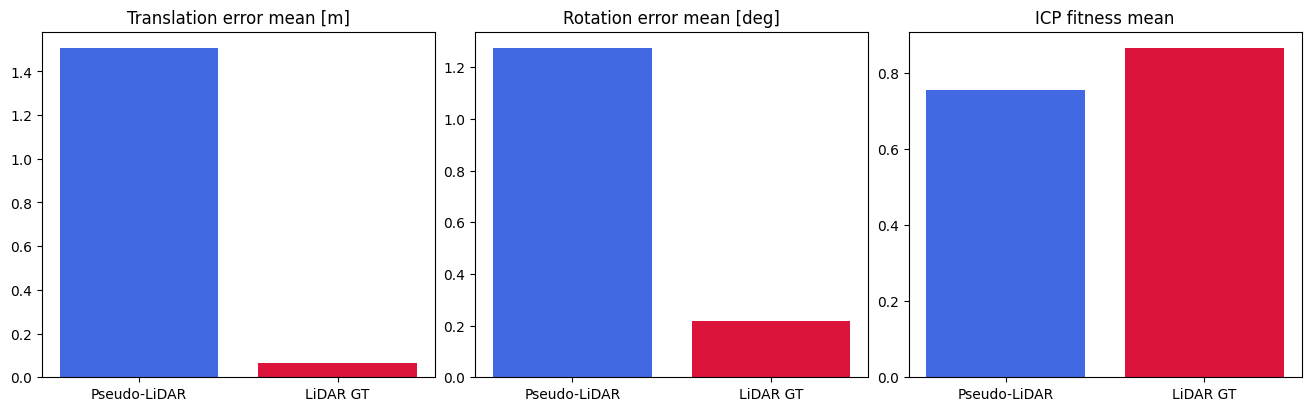

In [4]:
labels = ['Pseudo-LiDAR', 'LiDAR GT']
trans = [baseline_summary[k]['translation_error_mean_m'] for k in labels]
rot = [baseline_summary[k]['rotation_error_mean_deg'] for k in labels]
fit = [baseline_summary[k]['fitness_mean'] for k in labels]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
axes[0].bar(labels, trans, color=['royalblue', 'crimson'])
axes[0].set_title('Translation error mean [m]')
axes[1].bar(labels, rot, color=['royalblue', 'crimson'])
axes[1].set_title('Rotation error mean [deg]')
axes[2].bar(labels, fit, color=['royalblue', 'crimson'])
axes[2].set_title('ICP fitness mean')
plt.show()


## 2. Localización del error: análisis por regiones

A continuación, el registro se separa según:
- distancia (`near`, `mid`, `far`),
- zona (`front`, `left`, `right`).

Este análisis permite determinar si el problema está distribuido de forma homogénea en el anillo o si se concentra en regiones concretas.


In [5]:
REGIONS['aggregate']


{'all': {'translation_error_mean_m': 2.178795623968157,
  'rotation_error_mean_deg': 3.594470517746576,
  'fitness_mean': 0.7991450457046032,
  'num_valid_pairs': 4},
 'near': {'translation_error_mean_m': 2.1621890421877223,
  'rotation_error_mean_deg': 5.410318448366911,
  'fitness_mean': 0.8626457127956901,
  'num_valid_pairs': 4},
 'mid': {'translation_error_mean_m': 3.215004787649115,
  'rotation_error_mean_deg': 4.811100102720677,
  'fitness_mean': 0.7596652560536041,
  'num_valid_pairs': 4},
 'far': {'translation_error_mean_m': 3.6524410437539445,
  'rotation_error_mean_deg': 1.4740083659815388,
  'fitness_mean': 0.7356486794006535,
  'num_valid_pairs': 4},
 'front': {'translation_error_mean_m': 1.9059026777944306,
  'rotation_error_mean_deg': 2.3303987058296873,
  'fitness_mean': 0.7518827944175293,
  'num_valid_pairs': 4},
 'left': {'translation_error_mean_m': 2.054467565461714,
  'rotation_error_mean_deg': 3.5634393646556033,
  'fitness_mean': 0.746707974622132,
  'num_valid_p

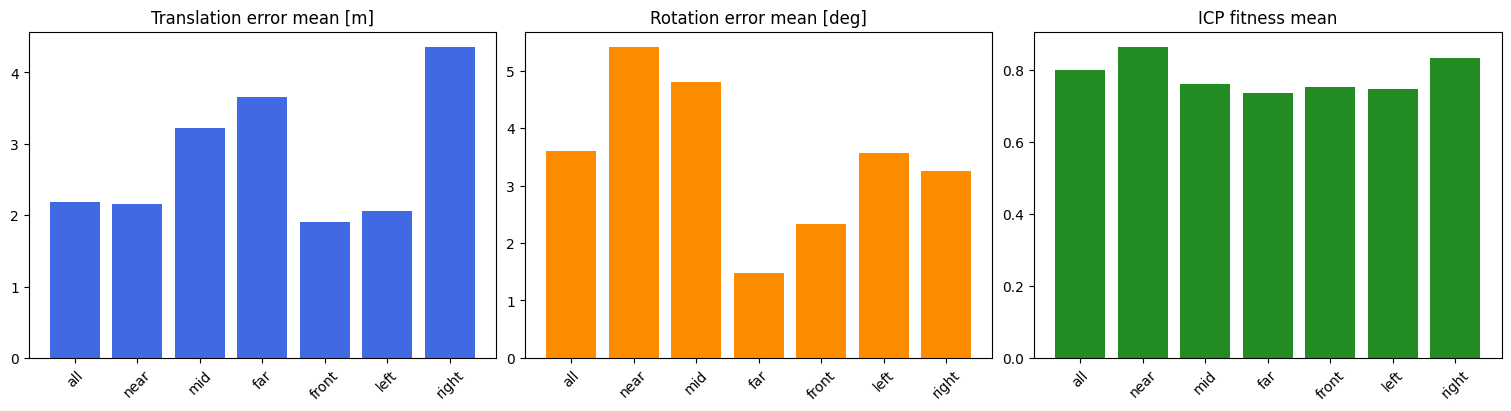

In [6]:
regions = ['all', 'near', 'mid', 'far', 'front', 'left', 'right']
trans_errors = [REGIONS['aggregate'][r]['translation_error_mean_m'] if REGIONS['aggregate'][r] else None for r in regions]
rot_errors = [REGIONS['aggregate'][r]['rotation_error_mean_deg'] if REGIONS['aggregate'][r] else None for r in regions]
fitness = [REGIONS['aggregate'][r]['fitness_mean'] if REGIONS['aggregate'][r] else None for r in regions]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
axes[0].bar(regions, trans_errors, color='royalblue')
axes[0].set_title('Translation error mean [m]')
axes[1].bar(regions, rot_errors, color='darkorange')
axes[1].set_title('Rotation error mean [deg]')
axes[2].bar(regions, fitness, color='forestgreen')
axes[2].set_title('ICP fitness mean')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.show()


## 3. Qué parte del anillo resulta más conveniente

A partir del análisis por regiones, se comparan directamente los subconjuntos:
- `all`,
- `front`,
- `front_left`,
- `front_right`.

La pregunta práctica en este punto es si, para una tarea tipo SLAM, conviene utilizar todo el pseudo-anillo o únicamente la parte más estable.


In [7]:
SUBSETS['aggregate']


{'all': {'translation_error_mean_m': 2.1787956239681567,
  'rotation_error_mean_deg': 3.594470517746576,
  'fitness_mean': 0.7991450457046032,
  'num_valid_pairs': 4},
 'front': {'translation_error_mean_m': 1.9059026777944297,
  'rotation_error_mean_deg': 2.3303987058296873,
  'fitness_mean': 0.7518827944175293,
  'num_valid_pairs': 4},
 'front_left': {'translation_error_mean_m': 1.9526080701093766,
  'rotation_error_mean_deg': 2.677978091848993,
  'fitness_mean': 0.7634236709577422,
  'num_valid_pairs': 4},
 'front_right': {'translation_error_mean_m': 2.539693754236223,
  'rotation_error_mean_deg': 2.7746391471370764,
  'fitness_mean': 0.8010933376947806,
  'num_valid_pairs': 4}}

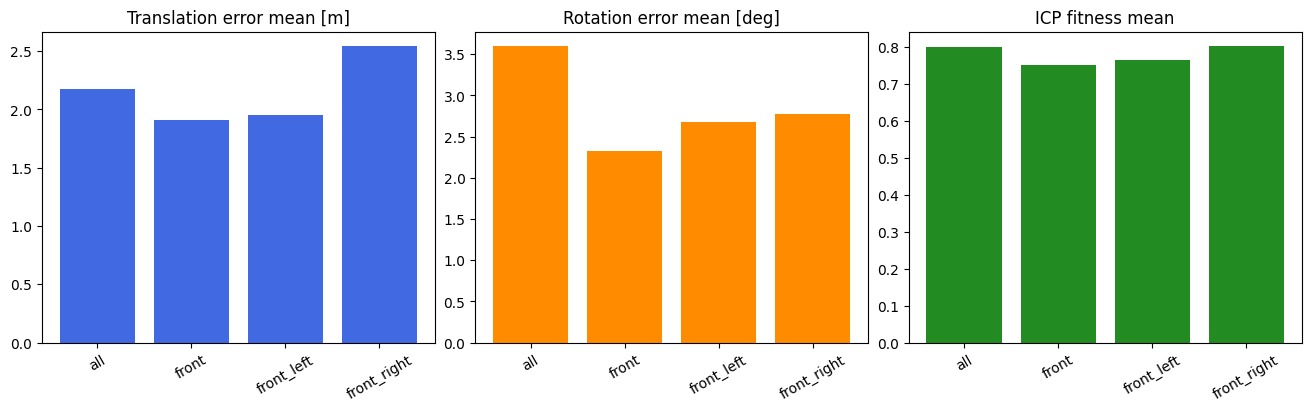

In [8]:
subsets = ['all', 'front', 'front_left', 'front_right']
trans = [SUBSETS['aggregate'][s]['translation_error_mean_m'] for s in subsets]
rot = [SUBSETS['aggregate'][s]['rotation_error_mean_deg'] for s in subsets]
fit = [SUBSETS['aggregate'][s]['fitness_mean'] for s in subsets]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
axes[0].bar(subsets, trans, color='royalblue')
axes[0].set_title('Translation error mean [m]')
axes[1].bar(subsets, rot, color='darkorange')
axes[1].set_title('Rotation error mean [deg]')
axes[2].bar(subsets, fit, color='forestgreen')
axes[2].set_title('ICP fitness mean')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.show()


## 4. Estrategia final de registro frontal

Una vez identificado `front` como el subconjunto más prometedor, se comparan dos estrategias:
- `front + ICP directo`,
- `front + alineación global + ICP`.

Con ello se pretende evaluar si aún es posible reducir el error actuando sobre el proceso de registro, sin modificar el modelo de depth.


In [9]:
FRONT_STRAT['aggregate']


{'front_icp_only_translation_error_mean_m': 1.9059026777944303,
 'front_icp_only_rotation_error_mean_deg': 2.3303987058296873,
 'front_icp_only_fitness_mean': 0.7518827944175293,
 'front_global_then_icp_translation_error_mean_m': 5.860979562688913,
 'front_global_then_icp_rotation_error_mean_deg': 24.471165499696102,
 'front_global_then_icp_fitness_mean': 0.7309622935977695}

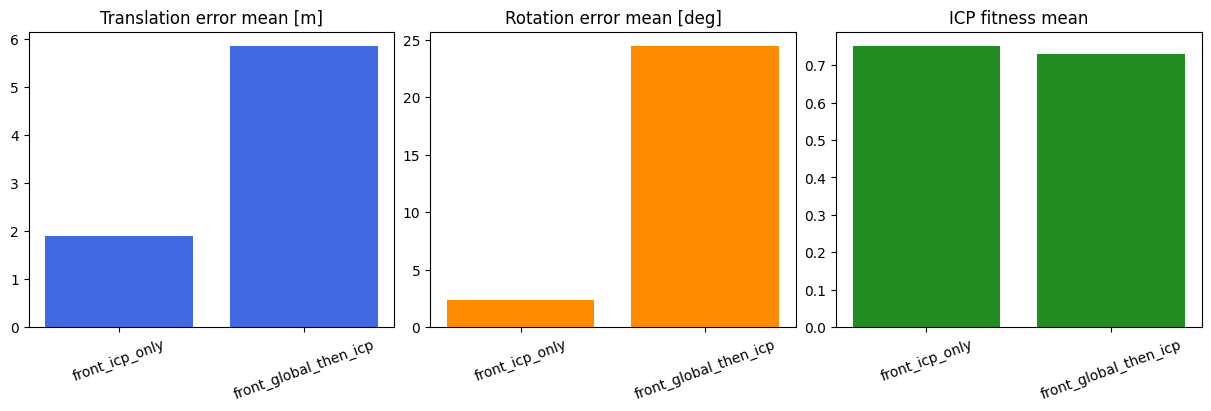

In [10]:
labels = ['front_icp_only', 'front_global_then_icp']
trans = [FRONT_STRAT['aggregate']['front_icp_only_translation_error_mean_m'], FRONT_STRAT['aggregate']['front_global_then_icp_translation_error_mean_m']]
rot = [FRONT_STRAT['aggregate']['front_icp_only_rotation_error_mean_deg'], FRONT_STRAT['aggregate']['front_global_then_icp_rotation_error_mean_deg']]
fit = [FRONT_STRAT['aggregate']['front_icp_only_fitness_mean'], FRONT_STRAT['aggregate']['front_global_then_icp_fitness_mean']]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
axes[0].bar(labels, trans, color='royalblue')
axes[0].set_title('Translation error mean [m]')
axes[1].bar(labels, rot, color='darkorange')
axes[1].set_title('Rotation error mean [deg]')
axes[2].bar(labels, fit, color='forestgreen')
axes[2].set_title('ICP fitness mean')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.show()


## 5. Tabla resumen

La tabla siguiente sintetiza la evolución experimental:
- baseline basada en todo el anillo,
- mejora obtenida mediante selección espacial,
- y mejora adicional debida a la estrategia de registro.


In [11]:
summary_table = {
    'all': {
        'translation_error_mean_m': SUBSETS['aggregate']['all']['translation_error_mean_m'],
        'rotation_error_mean_deg': SUBSETS['aggregate']['all']['rotation_error_mean_deg'],
        'fitness_mean': SUBSETS['aggregate']['all']['fitness_mean'],
    },
    'front': {
        'translation_error_mean_m': SUBSETS['aggregate']['front']['translation_error_mean_m'],
        'rotation_error_mean_deg': SUBSETS['aggregate']['front']['rotation_error_mean_deg'],
        'fitness_mean': SUBSETS['aggregate']['front']['fitness_mean'],
    },
    'front_global_then_icp': {
        'translation_error_mean_m': FRONT_STRAT['aggregate']['front_global_then_icp_translation_error_mean_m'],
        'rotation_error_mean_deg': FRONT_STRAT['aggregate']['front_global_then_icp_rotation_error_mean_deg'],
        'fitness_mean': FRONT_STRAT['aggregate']['front_global_then_icp_fitness_mean'],
    },
}
summary_table


{'all': {'translation_error_mean_m': 2.1787956239681567,
  'rotation_error_mean_deg': 3.594470517746576,
  'fitness_mean': 0.7991450457046032},
 'front': {'translation_error_mean_m': 1.9059026777944297,
  'rotation_error_mean_deg': 2.3303987058296873,
  'fitness_mean': 0.7518827944175293},
 'front_global_then_icp': {'translation_error_mean_m': 5.860979562688913,
  'rotation_error_mean_deg': 24.471165499696102,
  'fitness_mean': 0.7309622935977695}}

## 6. Conclusiones intermedias

### Resultados principales

1. La pseudo-LiDAR generada a partir de cámaras contiene información temporal útil para el registro, aunque se mantiene claramente por debajo del LiDAR real.

2. La utilidad de la pseudo-LiDAR no es homogénea alrededor del vehículo: la región frontal presenta el comportamiento más estable, mientras que los laterales, especialmente el derecho, introducen un error mayor.

3. El uso del pseudo-anillo completo no constituye la mejor estrategia para tareas tipo SLAM. La selección espacial de la nube mejora el comportamiento del registro.

4. La mejor configuración encontrada hasta esta fase consiste en emplear la pseudo-LiDAR frontal junto con una estrategia de alineación global seguida de ICP fino.

### Lectura práctica

La pseudo-LiDAR derivada de cámaras no sustituye a un LiDAR real para un SLAM robusto, pero sí puede proporcionar una base geométrica útil para el registro temporal si se utiliza de forma selectiva. En particular, la región frontal concentra la parte más fiable de la reconstrucción, y una estrategia de registro más informada mejora adicionalmente los resultados.
